#### Import required packages

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

#### Import sample data

In [3]:
my_df = pd.read_csv("data/sample_data_classification.csv")
print(my_df)

    output  input1  input2  input3
0        1     534     536     466
1        0     264     103     244
2        0     272     339     609
3        1     416     444     330
4        1     520     464     104
..     ...     ...     ...     ...
95       0     259     181     336
96       0     299     271     338
97       0     523     455     526
98       0     683     641     601
99       0     840     858     276

[100 rows x 4 columns]


#### Split data into input and output objects

In [4]:
X = my_df.drop(["output"], axis = 1)
y = my_df["output"]

#### Split data into training and test sets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

#### Instantiate our model object

In [7]:
clf = LogisticRegression(random_state = 42)

#### Train our model

In [8]:
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### Assess model accuracy

In [9]:
y_pred = clf.predict(X_test)
print(y_pred)
accuracy_score(y_test, y_pred)

[1 0 0 1 0 0 0 1 1 0 0 1 1 1 0 1 1 0 1 1]


0.8

In [11]:
y_pred_prob = clf.predict_proba(X_test)
print(y_pred_prob)

[[0.18627185 0.81372815]
 [0.92633532 0.07366468]
 [0.69737524 0.30262476]
 [0.13673133 0.86326867]
 [0.94374026 0.05625974]
 [0.87816011 0.12183989]
 [0.79520663 0.20479337]
 [0.14399264 0.85600736]
 [0.40934432 0.59065568]
 [0.84344711 0.15655289]
 [0.76010891 0.23989109]
 [0.49981017 0.50018983]
 [0.00158532 0.99841468]
 [0.06184789 0.93815211]
 [0.90660303 0.09339697]
 [0.42642881 0.57357119]
 [0.10544574 0.89455426]
 [0.68770982 0.31229018]
 [0.34086887 0.65913113]
 [0.2221485  0.7778515 ]]


#### Confusion matrix

In [12]:
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

[[8 3]
 [1 8]]


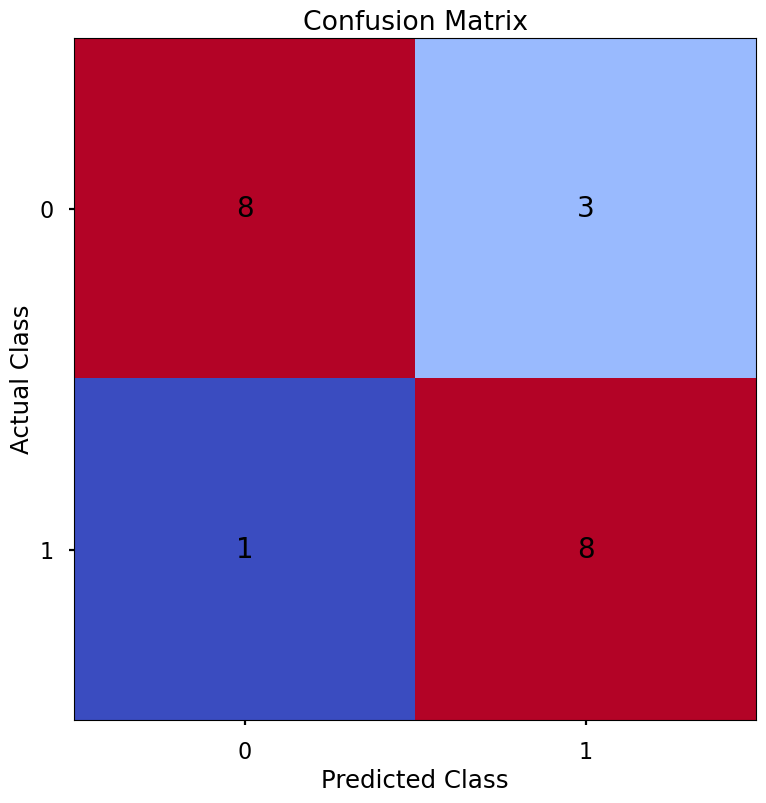

In [15]:
import numpy as np
plt.style.use("seaborn-v0_8-poster")
plt.matshow(conf_matrix, cmap = "coolwarm")
plt.gca().xaxis.tick_bottom()
plt.title("Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
for (i, j), corr_value in np.ndenumerate(conf_matrix):
    plt.text(j, i, corr_value, ha = "center", va = "center", fontsize = 20)
plt.show()